# Feature Engineering for Regression

**Project question:** Which transformations are available at prediction time and match the response definition?

By the end of this notebook, you should be able to:

- distinguish response transformations from predictor features
- create date, price, promotion, weather, size, and region features reproducibly
- avoid target leakage and export a documented modeling table

This notebook is a demonstration, not a homework assignment. The data are
synthetic and were generated for teaching; numerical results should not be
interpreted as evidence about a real organization or population.

In [1]:

from lite_setup import ensure_packages
await ensure_packages()

Using the current Python environment.


In [2]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
if not DATA.exists():
    raise FileNotFoundError("Open this notebook from the JupyterLite files root so data/ is available.")

In [3]:
sales = pd.read_csv(DATA / 'retail_sales_messy.csv').drop_duplicates().copy()
stores = pd.read_csv(DATA / 'store_metadata.csv')
weather = pd.read_csv(DATA / 'weather_weekly.csv')
for col in ['units', 'revenue', 'price', 'week', 'promotion']:
    sales[col] = pd.to_numeric(sales[col], errors='coerce')
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales.loc[sales['price'] > 50, 'price'] /= 100
valid = (
    ~sales[['units', 'revenue', 'price', 'week']].isna().any(axis=1)
    & sales['date'].notna()
    & sales['price'].gt(0)
    & sales['units'].le(1000)
)
sales = sales.loc[valid]
joined = sales.merge(stores, on='store_id', how='inner', validate='many_to_one')
joined = joined.merge(weather, on=['region', 'week'], how='left', validate='many_to_one')

In [4]:
features = joined.groupby(['store_id', 'week'], as_index=False).agg(
    week_start=('date', 'min'),
    units=('units', 'sum'),
    revenue=('revenue', 'sum'),
    avg_price=('price', 'mean'),
    promotion=('promotion', 'max'),
    store_size_sqft=('store_size_sqft', 'first'),
    temperature=('temperature', 'mean'),
    precipitation=('precipitation', 'mean'),
    region=('region', 'first'),
)
assert features['units'].gt(0).all()
features['log1p_units'] = np.log1p(features['units'])  # transformed response candidate
features['price_index'] = features['avg_price'] / features['avg_price'].median()
features['month'] = features['week_start'].dt.month
features['large_store'] = (features['store_size_sqft'] >= features['store_size_sqft'].median()).astype(int)
features = pd.get_dummies(features, columns=['region'], drop_first=True, dtype=int)
features.head()

,store_id,week,week_start,units,revenue,avg_price,promotion,store_size_sqft,temperature,precipitation,log1p_units,price_index,month,large_store,region_North,region_South,region_West
0,S001,1,2026-01-01,166.0,1641.74,9.89,0,1706,47.5,0.28,5.117994,0.977273,1,0,1,0,0
1,S001,2,2026-01-08,167.0,1573.14,9.42,0,1706,49.2,0.59,5.123964,0.930830,1,0,1,0,0
2,S001,3,2026-01-15,177.0,1612.47,9.11,0,1706,48.9,0.48,5.181784,0.900198,1,0,1,0,0
3,S001,4,2026-01-22,161.0,1503.74,9.34,0,1706,50.6,0.04,5.087596,0.922925,1,0,1,0,0
4,S001,5,2026-02-01,225.0,2074.50,9.22,1,1706,53.1,0.99,5.420535,0.911067,2,0,1,0,0


`log1p_units` is an alternative response, not a predictor when `units` is the outcome. Likewise, `revenue / units` is deliberately not created: it uses two possible outcomes and could leak target information. Predictor availability must be checked against the real prediction time.

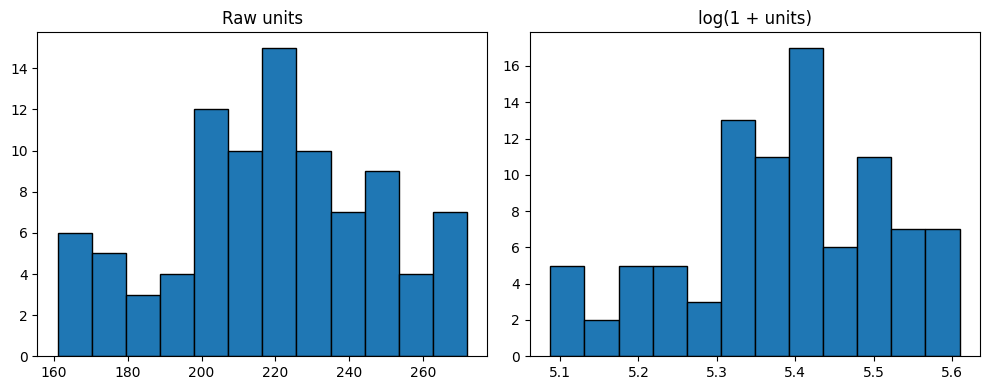

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(features['units'].dropna(), bins=12, edgecolor='black')
axes[0].set_title('Raw units')
axes[1].hist(features['log1p_units'].dropna(), bins=12, edgecolor='black')
axes[1].set_title('log(1 + units)')
plt.tight_layout()

A log transform changes the response scale and error interpretation; it is not automatically better. Residual diagnostics and the project objective should determine whether to model units or `log1p_units`.

In [6]:
scale_cols = ['avg_price', 'store_size_sqft', 'temperature', 'precipitation']
scaled_preview = (features[scale_cols] - features[scale_cols].mean()) / features[scale_cols].std(ddof=0)
scaled_preview.add_prefix('z_').head()

,z_avg_price,z_store_size_sqft,z_temperature,z_precipitation
0,-0.452581,-1.442792,-1.188313,-1.001702
1,-1.365767,-1.442792,-0.971322,-0.381186
2,-1.968082,-1.442792,-1.009615,-0.601369
3,-1.521203,-1.442792,-0.792625,-1.482101
4,-1.754357,-1.442792,-0.473521,0.419479


This standardized preview is not saved. For cross-validation or a test set, scaling parameters must be learned inside each training fold with a pipeline; fitting them on the full table would leak information.

In [7]:
OUTPUTS = Path('outputs')
OUTPUTS.mkdir(exist_ok=True)
out = OUTPUTS / 'retail_model_table.csv'
features.to_csv(out, index=False)
print(f'Wrote {len(features)} rows and {features.shape[1]} columns to {out}')
out

Wrote 92 rows and 17 columns to outputs\retail_model_table.csv


WindowsPath('outputs/retail_model_table.csv')

**Project reporting example:** We removed one exact duplicate, corrected one documented cents-versus-dollars entry, excluded invalid or incomplete records under stated rules, enforced many-to-one joins, aggregated to one store-week row, and created response, calendar, price, promotion, store, weather, and region fields. The synthetic extreme-units record was excluded under the stated teaching threshold.

**Transfer exercise:** Choose one response from your project. Make a two-column table of candidate features and whether each would truly be known at prediction time. Remove any target-derived or future-derived feature before modeling.